In [2]:
!pip install catboost

In [ ]:
"""
Пайплайн обучения и валидации CatBoost для предсказания оттока пользователей Netflix.

Ожидается CSV-файл с колонками:
customer_id, age, gender, subscription_type, watch_hours, last_login_days,
region, device, monthly_fee, churned, payment_method, number_of_profiles,
avg_watch_time_per_day, favorite_genre
"""
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TARGET = "churned"
DATA_PATH = "/data"  # замените на путь к вашему файлу
ARTIFACTS_PATH = Path("/artifacts")
ARTIFACTS_PATH.mkdir(exist_ok=True)

def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    return df


def prepare_features(df: pd.DataFrame):
    df = df.copy()

    if "customer_id" in df.columns:
        df = df.drop(columns=["customer_id"])

    cat_features = [
        "gender",
        "subscription_type",
        "region",
        "device",
        "payment_method",
        "favorite_genre",
    ]
    cat_features = [c for c in cat_features if c in df.columns]
    cat_features_values = {}

    for c in cat_features:
        df[c] = df[c].astype(str).fillna("missing")
        cat_features_values[c] = list(df[c].unique())

    cat_features_values['favorite_genre'].append('Other')

    X = df.drop(columns=[TARGET])
    y = df[TARGET].astype(int)

    return X, y, cat_features, cat_features_values

def split_data(X: pd.DataFrame, y: pd.Series):
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.2,
        stratify=y_train_full,
        random_state=RANDOM_STATE,
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def train_catboost(X_train, y_train, X_val, y_val, cat_features):
    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    val_pool = Pool(X_val, y_val, cat_features=cat_features)

    model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        early_stopping_rounds=100,
        auto_class_weights="Balanced",
        verbose=100,
    )

    model.fit(train_pool, eval_set=val_pool, use_best_model=True)
    return model

def evaluate(model, X_test, y_test, threshold=0.5):
    proba = model.predict_proba(X_test)[:, 1]
    preds = (proba >= threshold).astype(int)

    metrics = {
        "ROC-AUC": roc_auc_score(y_test, proba),
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
    }

    print("=== Метрики на тестовой выборке ===")
    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

    print("\n=== Confusion Matrix ===")
    print(confusion_matrix(y_test, preds))

    print("\n=== Classification Report ===")
    print(classification_report(y_test, preds))

    return metrics


def show_feature_importance(model, X_train, cat_features, top_n=15):
    pool = Pool(X_train, cat_features=cat_features)
    importances = model.get_feature_importance(pool)
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

    print(f"\n=== Топ-{top_n} важных признаков ===")
    print(feat_imp.head(top_n))
    return feat_imp

In [9]:
df = load_data(DATA_PATH)

In [10]:
display(df)
display(df.info())
print('-'*100)
display(df.describe())

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama
4996,18779bcb-ba2b-41da-b751-e70b812061ec,67,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,59,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

None

----------------------------------------------------------------------------------------------------


,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [11]:
X, y, cat_features, cat_features_values = prepare_features(df)

print(f"Категориальные признаки: {cat_features}")
print(f"Баланс классов:\n{y.value_counts(normalize=True)}\n")

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

model = train_catboost(X_train, y_train, X_val, y_val, cat_features)

metrics = evaluate(model, X_test, y_test)
show_feature_importance(model, X_train, cat_features)

Категориальные признаки: ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']
Баланс классов:
churned
1    0.503
0    0.497
Name: proportion, dtype: float64

0:	test: 0.9641647	best: 0.9641647 (0)	total: 7.24ms	remaining: 14.5s
100:	test: 0.9988437	best: 0.9988437 (100)	total: 709ms	remaining: 13.3s
200:	test: 0.9991500	best: 0.9991562 (185)	total: 1.29s	remaining: 11.6s
300:	test: 0.9995625	best: 0.9995625 (293)	total: 1.97s	remaining: 11.1s
400:	test: 0.9997562	best: 0.9997562 (398)	total: 2.76s	remaining: 11s
500:	test: 0.9997625	best: 0.9997812 (416)	total: 3.52s	remaining: 10.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9997812445
bestIteration = 416

Shrink model to first 417 iterations.
=== Метрики на тестовой выборке ===
ROC-AUC: 0.9997
Accuracy: 0.9910
Precision: 0.9881
Recall: 0.9940
F1: 0.9911

=== Confusion Matrix ===
[[491   6]
 [  3 500]]

=== Classification Report ===
              precision    recall  f1-scor

last_login_days           23.113378
watch_hours               21.277192
avg_watch_time_per_day    18.759165
number_of_profiles        14.898860
payment_method             8.358856
monthly_fee                7.839347
subscription_type          5.158940
device                     0.169156
gender                     0.135448
favorite_genre             0.123454
age                        0.112674
region                     0.053530
dtype: float64

порог 0.982: recall 0.751, precision 1.000


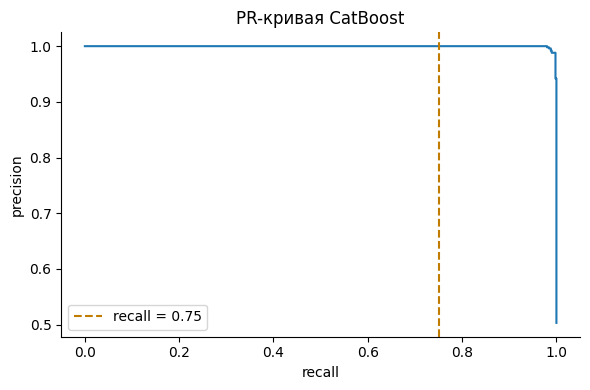

In [ ]:
from sklearn.metrics import precision_recall_curve

y_proba = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
mask = recall[:-1] >= 0.75
best_threshold = thresholds[mask].max()
pred = (y_proba >= best_threshold).astype(int)

print(f"порог {best_threshold:.3f}: recall {recall_score(y_test, pred):.3f}, "
      f"precision {precision_score(y_test, pred):.3f}")

plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.axvline(0.75, color="#C07C00", linestyle="--", label="recall = 0.75")
plt.xlabel("recall")
plt.ylabel("precision")

plt.title("PR-кривая CatBoost")
plt.legend()
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [13]:
num_features = list(df.columns[(df.dtypes != object) & (df.columns != 'churned')])

In [ ]:
import catboost
import sklearn

metadata = {
    "model_name": "churn-model",
    "model_version": "1.0",
    "trained_at": pd.Timestamp.utcnow().isoformat(timespec="seconds"),
    "n_train": len(X_train),
    "features": list(X.columns),
    "numeric_cols": num_features,
    "categorical_cols": cat_features,
    "categorical_cols_values": cat_features_values,
    "threshold": float(round(best_threshold, 4)),
    "metrics_test": {k: round(float(v), 4) for k, v in metrics.items() if k != "model"},
    "libs": \
        {"pandas": pd.__version__, \
         "scikit-learn": sklearn.__version__, \
         "catboost": catboost.__version__},
}

In [15]:
import joblib

artifact = {
    "model": model,
    "metadata": metadata
}

joblib.dump(
    artifact,
    ARTIFACTS_PATH / "churn_model.joblib"
)

['/kaggle/working/artifacts/churn_model.joblib']

In [16]:
artifact = joblib.load(ARTIFACTS_PATH / "churn_model.joblib")

model = artifact["model"]
metadata = artifact["metadata"]

threshold = metadata["threshold"]

frame = pd.DataFrame([X_test.iloc[0].to_dict()])[metadata["features"]]

score = float(model.predict_proba(frame)[0, 1])

print(json.dumps({
    "score": round(score, 4),
    "churn": bool(score >= threshold),
    "true_churn": bool(y_test.iloc[0]),
    "model_version": metadata["model_version"],
}, ensure_ascii=False))


{"score": 0.0002, "churn": false, "true_churn": false, "model_version": "1.0"}


In [17]:
batch_score = model.predict_proba(X_test)[0, 1]
assert abs(batch_score - score) < 1e-9, "train-serve skew: одна строка и батч дают разные ответы"
print("одна строка и батч совпадают до 1e-9")


одна строка и батч совпадают до 1e-9
